<a href="https://colab.research.google.com/github/akirakudo901/CVAE-EEG/blob/akira-model-training/440project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
# Mount your google drive to the /content/drive directory.
# This ensures that files changes remain saved in your drive.
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# clone the GitHub repo to be able to run code
%cd /content/drive/MyDrive/440_project/Akira
# !git clone -b akira-model-training --single-branch https://github.com/akirakudo901/CVAE-EEG.git
# !git pull
%cd "CVAE-EEG"

/content/drive/.shortcut-targets-by-id/1qIl3IhFywmZpD0gp4aNxpg2BAhUflWWW/440_project/Akira
/content/drive/.shortcut-targets-by-id/1qIl3IhFywmZpD0gp4aNxpg2BAhUflWWW/440_project/Akira/CVAE-EEG


In [5]:
DATA_LOCATION = r'../../data/ISRUC_S3.npz'

In [11]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os

from model.cvae_model import CVAE, loss_function

def train_cvae():
    # =====================================================
    # 1. Prepare Data
    # =====================================================
    data = np.load(DATA_LOCATION)
    eeg_data = data['Fold_data'].astype(np.float32)   # shape (10, 764, 10, 3000)
    labels_data = data['Fold_label'].astype(np.float32)  # shape (10, 764, 5)

    # reshape
    eeg_data = eeg_data.reshape(-1, 10, 3000)     # (7640, 10, 3000)
    labels_data = labels_data.reshape(-1, 5)      # (7640, 5)

    # (Optional) z-score or min-max
    # mean_val, std_val = eeg_data.mean(), eeg_data.std()
    # eeg_data = (eeg_data - mean_val)/(std_val + 1e-8)

    eeg_data = torch.from_numpy(eeg_data)
    labels_data = torch.from_numpy(labels_data)

    dataset = TensorDataset(eeg_data, labels_data)
    dataloader = DataLoader(dataset, batch_size=8, shuffle=True, drop_last=True)

    # =====================================================
    # 2. Init Model
    # =====================================================
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CVAE(
        input_channels=10,
        input_length=3000,
        num_classes=5,
        label_emb_dim=16,
        latent_dim=64,
        hidden_dims_encoder=[32, 64, 128],
        hidden_dims_decoder=[128, 64, 10],
        use_label_emb=False
    ).to(device)

    # =====================================================
    # 3. Optimizer & Hyperparams
    # =====================================================
    # AKIRA: initial value for lr given in the notebook was 1e-4
    # if I change this to 1e-3, the KLD term explodes and training cannot be continued
    # trying to fix that
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    epochs = 50
    kl_anneal_start = 0.0
    kl_anneal_end = 1.0
    kl_anneal_epochs = 10
    # alpha = 1.0         # classifier loss weight
    recon_weight = 1.0  # scale reconstruction MSE

    os.makedirs("checkpoints", exist_ok=True)

    # =====================================================
    # 4. Training Loop
    # =====================================================
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kld = 0.0
        # total_cls = 0.0

        # linearly ramp up the KL weight
        if epoch <= kl_anneal_epochs:
            kld_weight = kl_anneal_start + (kl_anneal_end - kl_anneal_start)*(epoch/kl_anneal_epochs)
        else:
            kld_weight = kl_anneal_end

        for batch_idx, (x, y) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            # recon, mu, logvar, logits = model(x, y)
            # loss, recon_loss, kld, cls_loss = loss_function(
            #     recon, x, mu, logvar, logits, y,
            #     kld_weight=kld_weight,
            #     alpha=alpha,
            #     recon_weight=recon_weight
            # )
            recon, mu, logvar = model(x, y)
            loss, recon_loss, kld = loss_function(
                recon, x, mu, logvar, kld_weight=kld_weight
            )
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kld += kld.item()
            # total_cls += cls_loss.item()

        avg_loss = total_loss / len(dataloader)
        avg_recon = total_recon / len(dataloader)
        avg_kld = total_kld / len(dataloader)
        # avg_cls = total_cls / len(dataloader)

        print(f"Epoch [{epoch}/{epochs}] "
              f"| Loss: {avg_loss:.4f} "
              f"| Recon: {avg_recon:.4f} "
              f"| KLD: {avg_kld:.4f} "
            #   f"| CLS: {avg_cls:.4f} "
              f"| kld_weight: {kld_weight:.4f} ")

    # =====================================================
    # 5. Save Model
    # =====================================================
    model_save_name = "checkpoints/cvae_eeg_" + str(epochs) + ".pth"
    torch.save(model.state_dict(), model_save_name)
    print("Training completed and model saved at " + model_save_name)

if __name__ == "__main__":
    train_cvae()

Epoch [1/50] | Loss: 31842257066.2347 | Recon: 5.0197 | KLD: 318422553603.7623 | kld_weight: 0.1000 
Epoch [2/50] | Loss: nan | Recon: nan | KLD: nan | kld_weight: 0.2000 


KeyboardInterrupt: 

In [ ]:
!python3 train.py

Epoch [1/150] | Loss: 25.3076 | Recon: 4.9823 | KLD: 1.9222 | CLS: 0.2041 | kld_weight: 0.1000 
Epoch [2/150] | Loss: 25.2000 | Recon: 4.9811 | KLD: 1.0182 | CLS: 0.0907 | kld_weight: 0.2000 
Epoch [3/150] | Loss: 25.1994 | Recon: 4.9811 | KLD: 0.6967 | CLS: 0.0849 | kld_weight: 0.3000 
Epoch [4/150] | Loss: 25.2243 | Recon: 4.9811 | KLD: 0.5662 | CLS: 0.0925 | kld_weight: 0.4000 
Epoch [5/150] | Loss: 25.2299 | Recon: 4.9810 | KLD: 0.4671 | CLS: 0.0912 | kld_weight: 0.5000 
Epoch [6/150] | Loss: 25.2172 | Recon: 4.9810 | KLD: 0.3808 | CLS: 0.0837 | kld_weight: 0.6000 
Epoch [7/150] | Loss: 25.2154 | Recon: 4.9810 | KLD: 0.3278 | CLS: 0.0812 | kld_weight: 0.7000 
Epoch [8/150] | Loss: 25.2040 | Recon: 4.9809 | KLD: 0.2794 | CLS: 0.0758 | kld_weight: 0.8000 
Epoch [9/150] | Loss: 25.1912 | Recon: 4.9809 | KLD: 0.2371 | CLS: 0.0732 | kld_weight: 0.9000 
Epoch [10/150] | Loss: 25.1901 | Recon: 4.9808 | KLD: 0.2166 | CLS: 0.0693 | kld_weight: 1.0000 
Epoch [11/150] | Loss: 25.1379 | Recon:

In [ ]:
!python3 experiment.py

Using device: cuda
Generating t-SNE latent space plot...
Figure(800x600)
Saved t-SNE plot to results/latent_tsne.png ✅
Generating EEG samples by condition...
Figure(1200x300)
Saved EEG plot for Stage 0 → results/generated_stage_0.png ✅
Figure(1200x300)
Saved EEG plot for Stage 1 → results/generated_stage_1.png ✅
Figure(1200x300)
Saved EEG plot for Stage 2 → results/generated_stage_2.png ✅
Figure(1200x300)
Saved EEG plot for Stage 3 → results/generated_stage_3.png ✅
Figure(1200x300)
Saved EEG plot for Stage 4 → results/generated_stage_4.png ✅
Evaluating reconstruction quality...
Average MSE (channel 0): 1.803922
Average Pearson Correlation (channel 0): 0.444309
Figure(1200x300)
Saved reconstruction comparison to results/reconstruction_example_0.png ✅
Figure(1200x300)
Saved reconstruction comparison to results/reconstruction_example_1.png ✅
Figure(1200x300)
Saved reconstruction comparison to results/reconstruction_example_2.png ✅


Using device: cuda
Evaluating reconstruction quality...
Average MSE (channel 0): 2.177836
Average Pearson Correlation (channel 0): 0.255646


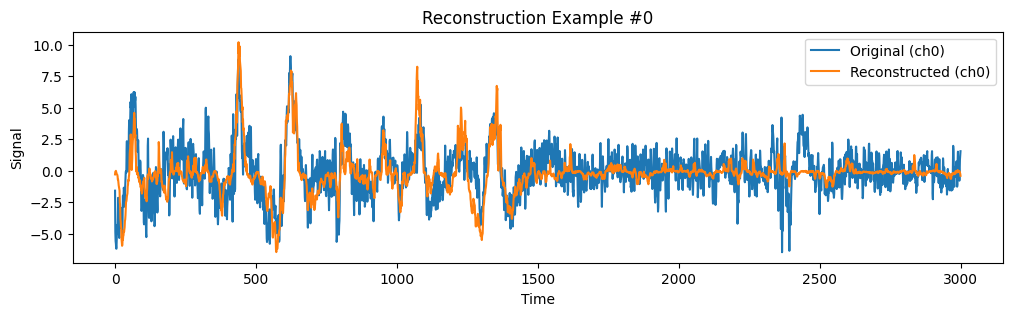

Saved reconstruction comparison to results/reconstruction_example_0.png ✅


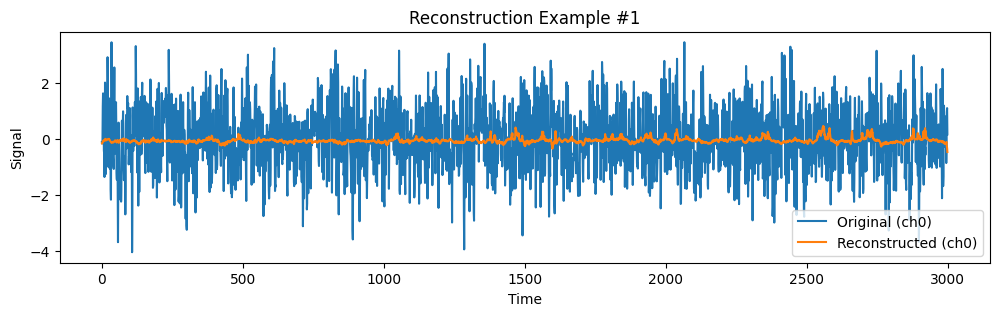

Saved reconstruction comparison to results/reconstruction_example_1.png ✅


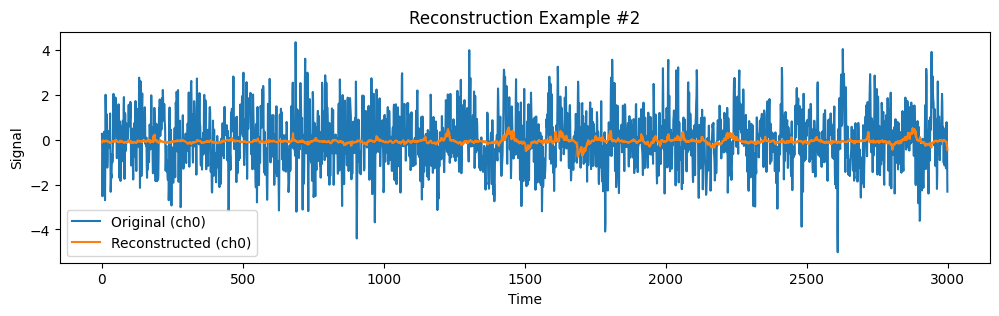

Saved reconstruction comparison to results/reconstruction_example_2.png ✅


In [7]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

from model.cvae_model import CVAE, loss_function
from scipy.stats import pearsonr

def load_model_and_data():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # === Load trained model ===
    model = CVAE(
        input_channels=10,
        input_length=3000,
        num_classes=5,
        label_emb_dim=16,
        latent_dim=64,
        hidden_dims_encoder=[32, 64, 128],
        hidden_dims_decoder=[128, 64, 10],
        use_label_emb=False
    ).to(device)

    checkpoint_path = "checkpoints/cvae_eeg_150.pth"
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}.")

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    # === Load real data for analysis
    data = np.load(DATA_LOCATION)
    eeg_data = data['Fold_data'].astype(np.float32)  # shape (10, 764, 10, 3000)
    labels_data = data['Fold_label'].astype(np.float32) # shape (10, 764, 5)

    eeg_data = eeg_data.reshape(-1, 10, 3000)
    labels_data = labels_data.reshape(-1, 5)

    # (Optional) if you used z-score in training, do same here
    # mean_val, std_val = eeg_data.mean(), eeg_data.std()
    # eeg_data = (eeg_data - mean_val)/(std_val + 1e-8)

    eeg_tensor = torch.from_numpy(eeg_data)
    label_tensor = torch.from_numpy(labels_data)
    dataset = TensorDataset(eeg_tensor, label_tensor)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

    return model, dataloader, device

def visualize_latent_space(model, dataloader, device):
    print("Generating t-SNE latent space plot...")
    all_mu = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            mu, logvar = model.encode(x, y)
            all_mu.append(mu.cpu())
            all_labels.append(y.cpu())

    all_mu = torch.cat(all_mu).numpy()
    all_labels = torch.cat(all_labels).numpy()
    label_ids = all_labels.argmax(axis=1)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    mu_2d = tsne.fit_transform(all_mu)

    plt.figure(figsize=(8, 6))
    for i in range(5):
        idx = (label_ids == i)
        plt.scatter(mu_2d[idx, 0], mu_2d[idx, 1], label=f"Stage {i}", alpha=0.6)
    plt.legend()
    plt.title("t-SNE of Latent Space")

    os.makedirs("results", exist_ok=True)
    plt.savefig("results/latent_tsne.png")
    plt.show()
    print("Saved t-SNE plot to results/latent_tsne.png ✅")

def generate_samples(model, device, latent_dim=64):
    print("Generating EEG samples by condition...")
    model.eval()
    os.makedirs("results", exist_ok=True)

    with torch.no_grad():
        z = torch.randn(1, latent_dim).to(device)
        for i in range(5):
            label = torch.zeros(1, 5).to(device)
            label[0, i] = 1  # one-hot for stage i

            gen = model.decode(z, label)  # shape: (1, 10, 3000)

            plt.figure(figsize=(12, 3))
            plt.plot(gen[0, 0].cpu().numpy())  # just channel 0
            plt.title(f"Generated EEG Sample (Stage {i})")
            plt.xlabel("Time")
            plt.ylabel("Signal")
            plt.savefig(f"results/generated_stage_{i}.png")
            plt.show()
            print(f"Saved EEG plot for Stage {i} → results/generated_stage_{i}.png ✅")


def evaluate_reconstruction_quality(model, dataloader, device, num_examples_to_plot=3):
    """
    Evaluate model's reconstruction performance:
      - Compute average MSE & Pearson correlation across dataset
      - Plot original vs reconstructed for a few random examples
    """
    print("Evaluating reconstruction quality...")
    model.eval()

    total_mse = 0.0
    total_corr = 0.0
    count = 0

    # We'll store a few examples for visualization:
    examples_data = []
    examples_recon = []

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)

            # Forward pass
            recon, mu, logvar = model(x, y)

            x_np = x.cpu().numpy()
            recon_np = recon.cpu().numpy()

            batch_size = x_np.shape[0]
            for i in range(batch_size):
                # We'll just measure channel 0 for simplicity
                original_0 = x_np[i, 0]
                recon_0 = recon_np[i, 0]

                # 1) MSE
                mse_i = np.mean((original_0 - recon_0)**2)
                total_mse += mse_i

                # 2) Pearson correlation
                corr_i = 0.0
                if (np.std(original_0) > 1e-12) and (np.std(recon_0) > 1e-12):
                    from scipy.stats import pearsonr
                    corr_i, _ = pearsonr(original_0, recon_0)
                total_corr += corr_i

            count += batch_size

            if len(examples_data) < num_examples_to_plot:
                examples_data.append(x_np[0])
                examples_recon.append(recon_np[0])

    avg_mse = total_mse / count
    avg_corr = total_corr / count

    print(f"Average MSE (channel 0): {avg_mse:.6f}")
    print(f"Average Pearson Correlation (channel 0): {avg_corr:.6f}")

    os.makedirs("results", exist_ok=True)
    for i in range(len(examples_data)):
        original = examples_data[i]
        reconst = examples_recon[i]

        fig = plt.figure(figsize=(12, 3))
        plt.plot(original[0], label="Original (ch0)")
        plt.plot(reconst[0], label="Reconstructed (ch0)")
        plt.legend()
        plt.title(f"Reconstruction Example #{i}")
        plt.xlabel("Time")
        plt.ylabel("Signal")
        plt.savefig(f"results/reconstruction_example_{i}.png")
        plt.show()
        print(f"Saved reconstruction comparison to results/reconstruction_example_{i}.png ✅")

if __name__ == "__main__":
    model, dataloader, device = load_model_and_data()

    # 1) Visualize latent
    # visualize_latent_space(model, dataloader, device)

    # # 2) Generate some samples
    # generate_samples(model, device, latent_dim=64)

    # 3) Evaluate Reconstruction
    evaluate_reconstruction_quality(model, dataloader, device, num_examples_to_plot=3)
